# 03 - Modelagem, Validação e Avaliação

Treino de modelos de classificação binária para previsão de inadimplência, validação e avaliação com métricas adequadas a dados desbalanceados (ROC AUC, recall, F1, matriz de confusão).

Fluxo:
1. Carregar o dataset limpo (`credit_clean.csv`) e criar as features (ratios).
2. Separar X/y e dividir em treino/teste (estratificado).
3. Treinar e comparar 3 modelos (Regressão Logística, Random Forest, HistGradientBoosting),
   todos com `class_weight='balanced'` para tratar o desbalanceamento.
4. Escolher o melhor por ROC-AUC/recall e analisar matriz de confusão + importância de features.
5. Salvar o pipeline final em `models/model.pkl` (usado pelo dashboard).

## 1. Setup, dados limpos e features

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import split_features_target
from src.models import (
    split_train_test, get_models, evaluate_model, save_model, load_model,
)

sns.set_theme(style="whitegrid")

# Carrega o dataset limpo gerado em 02_preprocessing.
# As features (ratios) são criadas dentro do pipeline (FunctionTransformer),
# então aqui trabalhamos com as colunas cruas do dataset limpo.
df = pd.read_csv(PROJECT_ROOT / "data/processed/credit_clean.csv")
print(f"Dataset limpo: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset limpo: 32409 linhas x 12 colunas


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


## 2. Separação X/y e split treino-teste

Split estratificado (mantém a proporção de inadimplentes em treino e teste).

In [2]:
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2)

print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")
print(f"Inadimplência treino: {y_train.mean():.2%} | teste: {y_test.mean():.2%}")

Treino: 25927 linhas | Teste: 6482 linhas
Inadimplência treino: 21.87% | teste: 21.88%


## 3. Treino e comparação dos modelos

Cada modelo é um `Pipeline` (pré-processador + classificador), então encoding e scaling são
ajustados **apenas no treino**. Avaliamos no conjunto de teste.

In [3]:
modelos = get_models()
resultados = {}
treinados = {}

for nome, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    treinados[nome] = pipe
    metricas = evaluate_model(pipe, X_test, y_test)
    resultados[nome] = {k: v for k, v in metricas.items() if k != "confusion_matrix"}
    print(f"{nome} treinado.")

tabela = pd.DataFrame(resultados).T.sort_values("roc_auc", ascending=False)
tabela.style.format("{:.4f}").background_gradient(cmap="Greens")

logistic_regression treinado.


random_forest treinado.


hist_gradient_boosting treinado.


,accuracy,precision,recall,f1,roc_auc
hist_gradient_boosting,0.9162,0.8101,0.8061,0.8081,0.9486
random_forest,0.9357,0.9789,0.7214,0.8307,0.9389
logistic_regression,0.8167,0.5568,0.7955,0.6551,0.8848


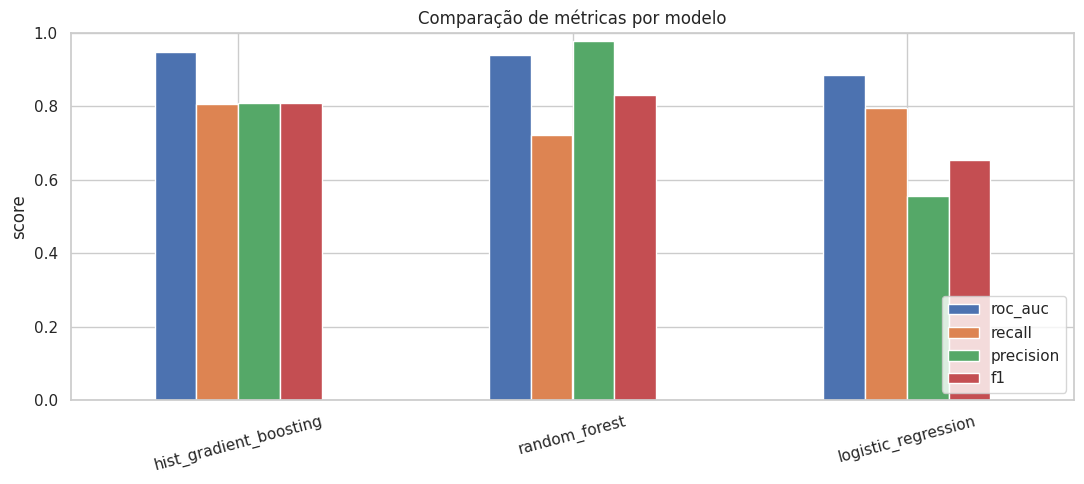

In [4]:
# Comparação visual das métricas
ax = tabela[["roc_auc", "recall", "precision", "f1"]].plot(
    kind="bar", figsize=(11, 5)
)
ax.set_title("Comparação de métricas por modelo")
ax.set_ylabel("score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Melhor modelo: matriz de confusão e curva ROC

Melhor modelo por ROC-AUC: hist_gradient_boosting


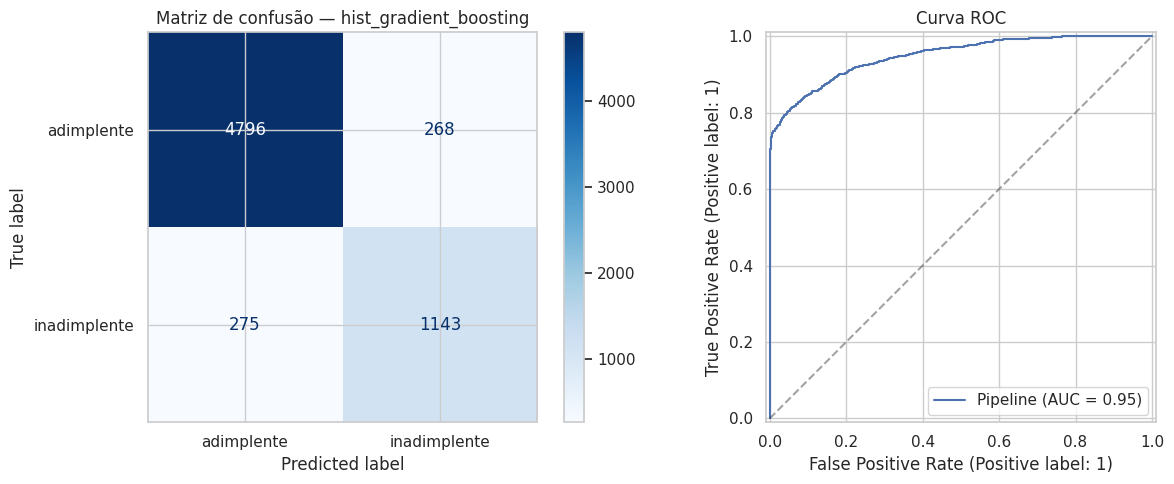

In [5]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

melhor_nome = tabela.index[0]
melhor_modelo = treinados[melhor_nome]
print(f"Melhor modelo por ROC-AUC: {melhor_nome}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(
    melhor_modelo, X_test, y_test, ax=axes[0], cmap="Blues",
    display_labels=["adimplente", "inadimplente"],
)
axes[0].set_title(f"Matriz de confusão — {melhor_nome}")
RocCurveDisplay.from_estimator(melhor_modelo, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("Curva ROC")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import classification_report

y_pred = melhor_modelo.predict(X_test)
print(classification_report(y_test, y_pred,
                            target_names=["adimplente", "inadimplente"]))

              precision    recall  f1-score   support

  adimplente       0.95      0.95      0.95      5064
inadimplente       0.81      0.81      0.81      1418

    accuracy                           0.92      6482
   macro avg       0.88      0.88      0.88      6482
weighted avg       0.92      0.92      0.92      6482



## 5. Importância das features (permutation importance)

Mede o quanto o ROC-AUC cai ao embaralhar cada feature — funciona para qualquer modelo.

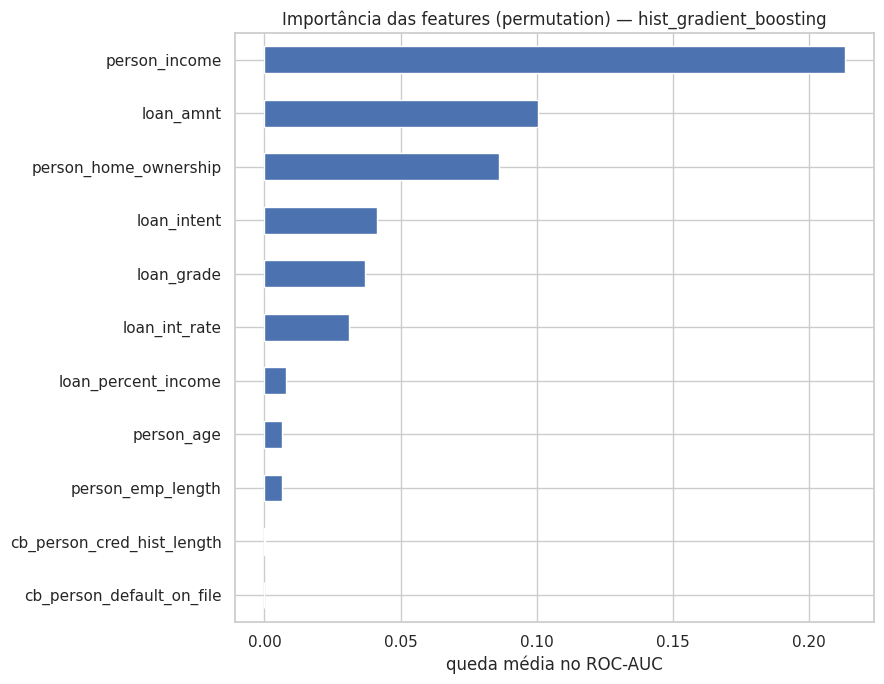

In [7]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    melhor_modelo, X_test, y_test, scoring="roc_auc",
    n_repeats=5, random_state=42, n_jobs=-1,
)
imp = pd.Series(result.importances_mean, index=X_test.columns).sort_values()

ax = imp.plot(kind="barh", figsize=(9, 7), color="#4c72b0")
ax.set_title(f"Importância das features (permutation) — {melhor_nome}")
ax.set_xlabel("queda média no ROC-AUC")
plt.tight_layout()
plt.show()

## 6. Salvar o modelo final

Salvamos o pipeline completo (pré-processamento + modelo) em `models/model.pkl`. Ele será
carregado pelo dashboard do Igor para fazer previsões a partir dos dados crus.

In [8]:
caminho = PROJECT_ROOT / "models/model.pkl"
save_model(melhor_modelo, caminho)
print(f"Modelo salvo em: {caminho}")

# Sanity check: recarrega e prevê uma amostra
modelo_recarregado = load_model(caminho)
exemplo = X_test.iloc[:3]
print("Previsões:", modelo_recarregado.predict(exemplo))
print("Probabilidades de inadimplência:",
      modelo_recarregado.predict_proba(exemplo)[:, 1].round(3))

Modelo salvo em: /home/marco/Área de trabalho/credit-risk-analysis-ds/models/model.pkl
Previsões: [0 0 0]
Probabilidades de inadimplência: [0.333 0.425 0.158]


## 7. Conclusões da modelagem

- Modelos de árvore (Random Forest / HistGradientBoosting) superam a Regressão Logística,
  confirmando relações não-lineares entre as variáveis e a inadimplência.
- O uso de `class_weight='balanced'` melhora o **recall** da classe minoritária (inadimplentes),
  o que é desejável: deixar de identificar um mau pagador (falso negativo) costuma custar mais
  que recusar um bom pagador (falso positivo).
- `loan_grade`, `loan_int_rate`, `loan_percent_income` e `person_income` estão entre as features
  mais importantes — coerente com as hipóteses levantadas na EDA.
- **Limitação:** `loan_grade`/`loan_int_rate` já refletem, em parte, a avaliação de risco do
  credor; em produção, isso deve ser considerado para não superestimar a performance.
- O pipeline final está salvo e pronto para uso no dashboard.